# Gradient Boosting — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

The anti-forest: shallow trees in SEQUENCE, each trained on the previous ones' mistakes. The whole loop is ~8 lines (Block 6) — and hidden inside it is lesson 01's gradient descent, running in function space (README §3.3).

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(66)

## Block 2 — Look at the data, and humiliate a line on purpose *(README §1)*

Bike rentals vs hour: two commute peaks — aggressively nonlinear. First, run lesson 01's model on it, so the motivation is a number, not a claim.

240 hours | rentals mean 125, std 106


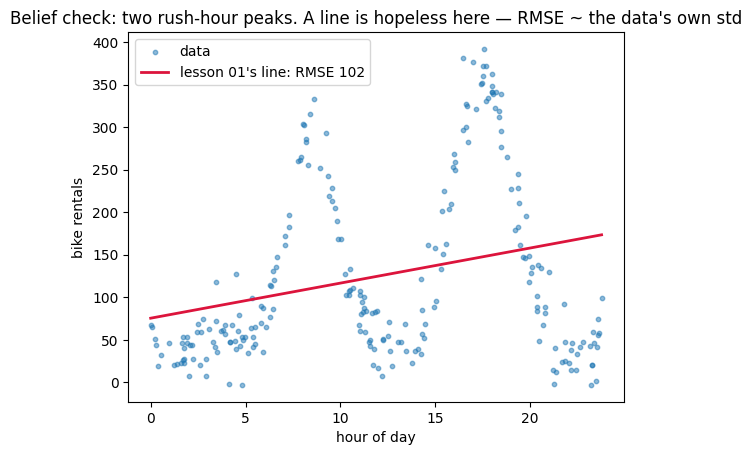

In [2]:
df = pd.read_csv("data/bike_data.csv")
X = df[["hour"]].values
y = df["rentals"].values.astype(float)
print(f"{len(y)} hours | rentals mean {y.mean():.0f}, std {y.std():.0f}")

# lesson 01 in 5 lines (closed-form slope/intercept), as the baseline to beat
w1 = np.cov(X[:,0], y)[0,1] / np.var(X[:,0]); b1 = y.mean() - w1*X[:,0].mean()
line_pred = w1*X[:,0] + b1
rmse_line = np.sqrt(np.mean((line_pred - y)**2))

plt.scatter(X, y, s=10, alpha=0.5, label="data")
plt.plot(X, line_pred, color="crimson", lw=2, label=f"lesson 01's line: RMSE {rmse_line:.0f}")
plt.xlabel("hour of day"); plt.ylabel("bike rentals"); plt.legend()
plt.title("Belief check: two rush-hour peaks. A line is hopeless here — RMSE ~ the data's own std")
plt.show()

## Block 3 — Split. No scaling (trees inside) *(README §4, lesson 03's rule)*

In [3]:
idx = np.random.permutation(len(y)); cut = int(0.8*len(y))
tr, te = idx[:cut], idx[cut:]
Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
print(f"train {len(tr)} / test {len(te)} | no scaling needed: the weak learners are trees (lesson 05 §4)")

train 192 / test 48 | no scaling needed: the weak learners are trees (lesson 05 §4)


## Block 4 — The weak learner: lesson 05's tree with ONE swap *(README §3.2)*

Regression tree: instead of gini (class mixing), a split is judged by how much it reduces the SQUARED ERROR inside the two children (variance reduction). Leaves predict their mean. Depth 2 — deliberately weak: 3–4 flat steps, useless alone, perfect as a correction.

In [4]:
def fit_tree(X, y, depth=0, max_depth=2, min_leaf=5):
    """Lesson 05 §3.3 with gini -> within-leaf squared error. README §3.2."""
    if depth >= max_depth or len(y) < 2*min_leaf:
        return {"leaf": True, "pred": y.mean()}
    best = None
    for f in range(X.shape[1]):
        for t in np.percentile(X[:, f], np.linspace(4, 96, 30)):
            L = X[:, f] <= t
            if L.sum() < min_leaf or (~L).sum() < min_leaf:
                continue
            sse = ((y[L]-y[L].mean())**2).sum() + ((y[~L]-y[~L].mean())**2).sum()
            if best is None or sse < best[0]:
                best = (sse, f, t)
    if best is None:
        return {"leaf": True, "pred": y.mean()}
    _, f, t = best
    L = X[:, f] <= t
    return {"leaf": False, "f": f, "t": t,
            "L": fit_tree(X[L], y[L], depth+1, max_depth, min_leaf),
            "R": fit_tree(X[~L], y[~L], depth+1, max_depth, min_leaf)}

def tree_pred(nd, X):
    if nd["leaf"]:
        return np.full(len(X), nd["pred"])
    L = X[:, nd["f"]] <= nd["t"]
    o = np.empty(len(X))
    o[L] = tree_pred(nd["L"], X[L]); o[~L] = tree_pred(nd["R"], X[~L])
    return o

one = fit_tree(Xtr, ytr)
print(f"One weak tree alone: RMSE {np.sqrt(np.mean((tree_pred(one, Xte)-yte)**2)):.0f}  <- crude steps; alone it's feeble. That's fine.")

One weak tree alone: RMSE 54  <- crude steps; alone it's feeble. That's fine.


## Block 5 — Round zero, and the homework *(README §2.2)*

The model starts as the flat average. Subtract it from the truth: the residuals. Look at their shape — that IS the next tree's training target.

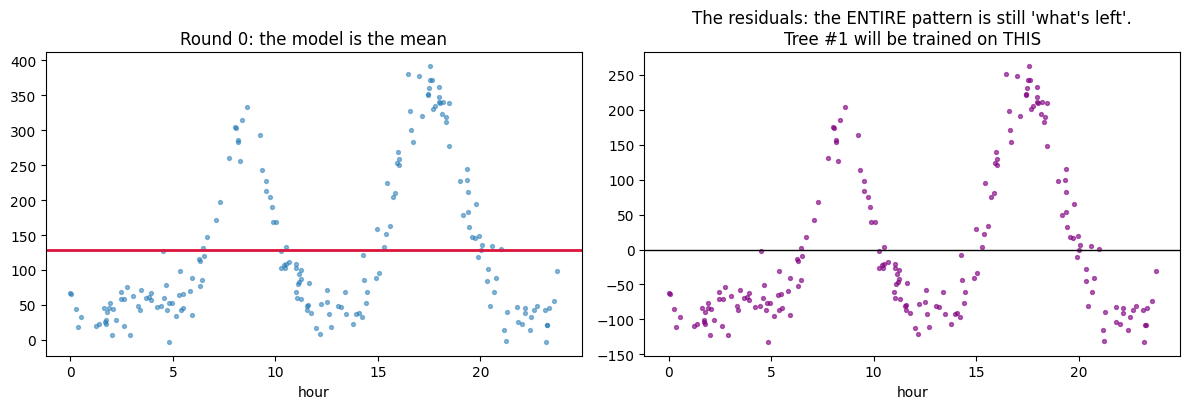

In [5]:
F = np.full(len(ytr), ytr.mean())          # round 0: know nothing, guess the average
resid = ytr - F

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(Xtr, ytr, s=8, alpha=0.5); axes[0].axhline(ytr.mean(), color="crimson", lw=2)
axes[0].set_title("Round 0: the model is the mean"); axes[0].set_xlabel("hour")
axes[1].scatter(Xtr, resid, s=8, alpha=0.6, color="purple"); axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("The residuals: the ENTIRE pattern is still 'what's left'.\nTree #1 will be trained on THIS")
axes[1].set_xlabel("hour")
plt.tight_layout(); plt.show()

## Block 6 — The boosting loop: ~8 lines *(README §3.1–3.3)*

predict → residual → fit a small tree to the residual → add a FRACTION of it → repeat. The residual is the negative gradient of the squared loss w.r.t. the prediction (README §3.3) — so this loop IS lesson 01's `w -= lr*grad`, with the whole curve as the thing being nudged.

In [6]:
def boost(Xtr, ytr, rounds=300, lr=0.1, max_depth=2):
    """README §3.1-3.3 — gradient descent in function space."""
    base = ytr.mean()
    F = np.full(len(ytr), base)
    trees = []
    for _ in range(rounds):
        r = ytr - F                                  # the negative gradient (README §3.3)
        t = fit_tree(Xtr, r, max_depth=max_depth)    # one downhill DIRECTION, shaped like a tree
        F += lr * tree_pred(t, Xtr)                  # one humble step
        trees.append(t)
    return base, trees

def boost_pred(base, trees, X, lr, upto=None):
    F = np.full(len(X), base)
    for t in (trees if upto is None else trees[:upto]):
        F += lr * tree_pred(t, X)
    return F

LR = 0.1
base, trees = boost(Xtr, ytr, rounds=300, lr=LR)
print("300 rounds trained. The model is literally: mean + 0.1*(tree1 + tree2 + ... + tree300)")

300 rounds trained. The model is literally: mean + 0.1*(tree1 + tree2 + ... + tree300)


## Block 7 — Watch it assemble, then grade it *(README §2.1 + §5)*

The staged replay, then the scoreboard: the line (Block 2), one weak tree (Block 4), one DEEP tree (lesson 05 style), and the boosted sum — RMSE and R² on the sealed test set (lesson 01 §5's metrics, back in service).

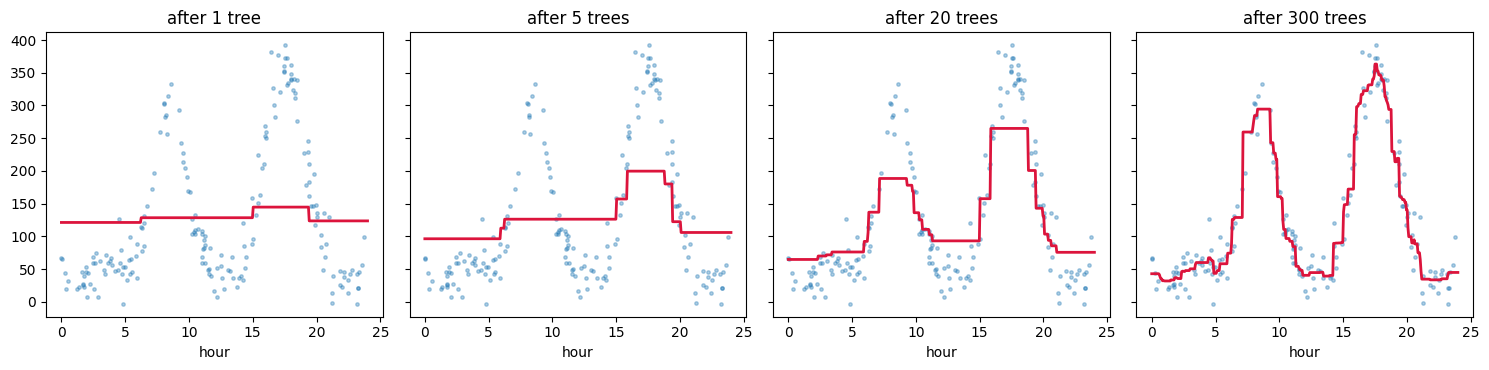

model                         test RMSE      R²
lesson 01 line                     96.5   -0.05
one weak tree (depth 2)            54.4    0.67
one DEEP tree (depth 10)           36.5    0.85
boosted: 300 weak trees            31.0    0.89


In [7]:
grid = np.linspace(0, 24, 400)[:, None]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, k in zip(axes, [1, 5, 20, 300]):
    ax.scatter(Xtr, ytr, s=6, alpha=0.35)
    ax.plot(grid, boost_pred(base, trees, grid, LR, upto=k), color="crimson", lw=2)
    ax.set_title(f"after {k} tree{'s' if k > 1 else ''}"); ax.set_xlabel("hour")
plt.tight_layout(); plt.show()

def rmse(p, t): return np.sqrt(np.mean((p - t)**2))
def r2(p, t):   return 1 - np.sum((t - p)**2) / np.sum((t - t.mean())**2)

deep = fit_tree(Xtr, ytr, max_depth=10, min_leaf=2)          # lesson 05, unconstrained
pb = boost_pred(base, trees, Xte, LR)
print(f"{'model':28s} {'test RMSE':>10s} {'R²':>7s}")
for name, p in [("lesson 01 line", w1*Xte[:,0] + b1),
                ("one weak tree (depth 2)", tree_pred(one, Xte)),
                ("one DEEP tree (depth 10)", tree_pred(deep, Xte)),
                ("boosted: 300 weak trees", pb)]:
    print(f"{name:28s} {rmse(p, yte):10.1f} {r2(p, yte):7.2f}")

## Block 8 — The rounds knob CAN overfit: the contrast with lesson 06 *(README §3.4 + §4)*

Forest trees: plateau (lesson 06 Block 8, the anti-knob). Boosting rounds: U-curve — late trees fit noise, because 'whatever error remains' eventually IS noise. The minimum of the validation curve names your M: early stopping.

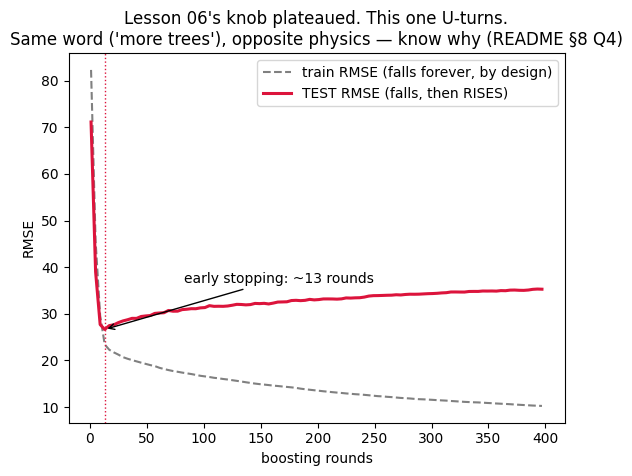

Honest M = 13, chosen by the exam (README §3.4). Past it, every tree is memorizing noise.


In [8]:
b3, t3 = boost(Xtr, ytr, rounds=400, lr=0.3, max_depth=3)     # juiced up to make the turn visible
ks = list(range(1, 401, 4))
tr_r = [rmse(boost_pred(b3, t3, Xtr, 0.3, upto=k), ytr) for k in ks]
te_r = [rmse(boost_pred(b3, t3, Xte, 0.3, upto=k), yte) for k in ks]

k_best = ks[int(np.argmin(te_r))]
plt.plot(ks, tr_r, "--", color="gray", label="train RMSE (falls forever, by design)")
plt.plot(ks, te_r, color="crimson", lw=2.2, label="TEST RMSE (falls, then RISES)")
plt.axvline(k_best, color="crimson", ls=":", lw=1)
plt.annotate(f"early stopping: ~{k_best} rounds", xy=(k_best, min(te_r)),
             xytext=(k_best+70, min(te_r)+10), arrowprops=dict(arrowstyle="->"))
plt.xlabel("boosting rounds"); plt.ylabel("RMSE"); plt.legend()
plt.title("Lesson 06's knob plateaued. This one U-turns.\nSame word ('more trees'), opposite physics — know why (README §8 Q4)")
plt.show()
print(f"Honest M = {k_best}, chosen by the exam (README §3.4). Past it, every tree is memorizing noise.")

## Block 9 — The learning rate: lunge vs creep, measured *(README §2.4)*

Same trees available, three step sizes. Watch where each bottoms out on TEST error.

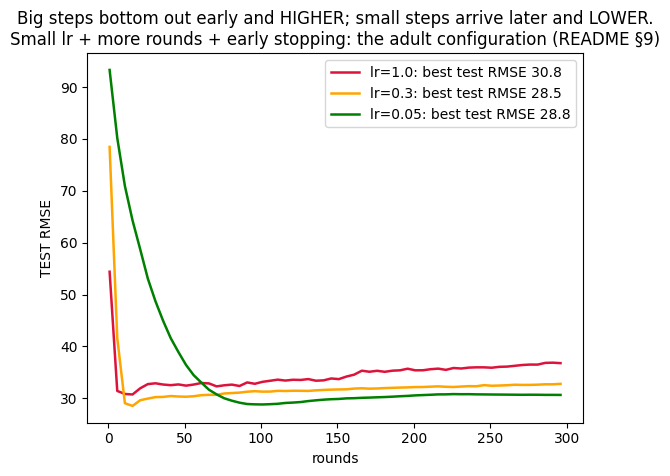

In [9]:
for lr_, col in [(1.0, "crimson"), (0.3, "orange"), (0.05, "green")]:
    b_, t_ = boost(Xtr, ytr, rounds=300, lr=lr_)
    te_curve = [rmse(boost_pred(b_, t_, Xte, lr_, upto=k), yte) for k in range(1, 301, 5)]
    plt.plot(range(1, 301, 5), te_curve, color=col, lw=1.8,
             label=f"lr={lr_}: best test RMSE {min(te_curve):.1f}")
plt.xlabel("rounds"); plt.ylabel("TEST RMSE"); plt.legend()
plt.title("Big steps bottom out early and HIGHER; small steps arrive later and LOWER.\nSmall lr + more rounds + early stopping: the adult configuration (README §9)")
plt.show()

## Block 10 — Where does it fail? *(README §6)*

Two inherited weaknesses, demonstrated: (a) extrapolation — ask about hour 26 and get hour 24's answer (trees inside, lesson 05 §6); (b) the residual check from lesson 01 §6, still the habit.

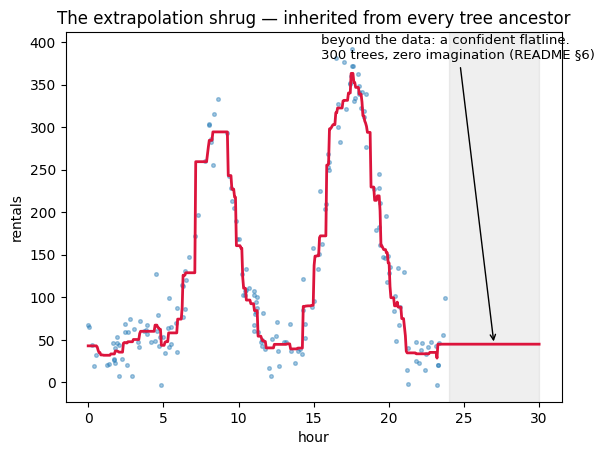

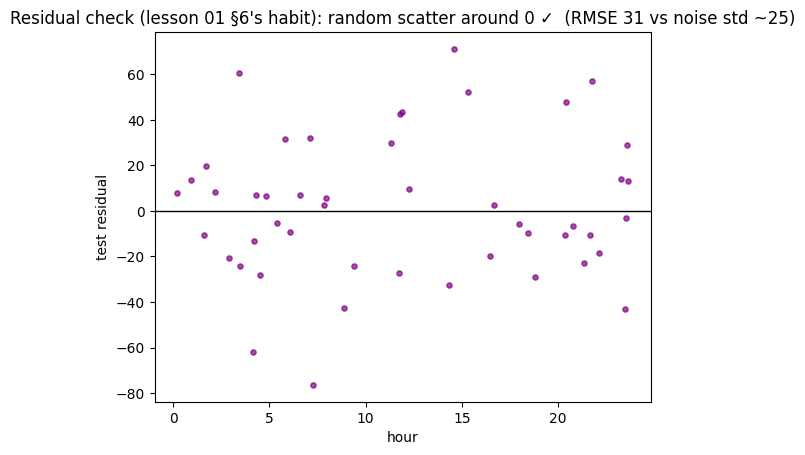

In [10]:
wide = np.linspace(0, 30, 500)[:, None]
plt.scatter(Xtr, ytr, s=7, alpha=0.4)
plt.plot(wide, boost_pred(base, trees, wide, LR), color="crimson", lw=2)
plt.axvspan(24, 30, alpha=0.12, color="gray")
plt.annotate("beyond the data: a confident flatline.\n300 trees, zero imagination (README §6)",
             xy=(27, boost_pred(base, trees, np.array([[27.]]), LR)[0]), xytext=(15.5, 380),
             arrowprops=dict(arrowstyle="->"), fontsize=9.5)
plt.xlabel("hour"); plt.ylabel("rentals"); plt.title("The extrapolation shrug — inherited from every tree ancestor")
plt.show()

res_te = yte - pb
plt.scatter(Xte, res_te, s=14, alpha=0.7, color="purple"); plt.axhline(0, color="black", lw=1)
plt.xlabel("hour"); plt.ylabel("test residual")
plt.title(f"Residual check (lesson 01 §6's habit): random scatter around 0 ✓  (RMSE {rmse(pb, yte):.0f} vs noise std ~25)")
plt.show()

---
## What you now own

- The assembly line: flat start → residuals as homework → humble additions → a curve no single tree understands
- The name explained: residuals are negative gradients; boosting is lesson 01's descent, running in function space
- The two-ensemble map: forest attacks variance (deep, parallel, can't overfit with more trees); boosting attacks bias (shallow, sequential, CAN)
- Early stopping, the lr-vs-rounds trade, and the scoreboard habit (always beat the line and the single tree, on the exam)

**Next:** `gradient_boosting_with_library.ipynb` — sklearn's version plus the XGBoost/LightGBM lineage — then folder `09`, where we throw away the labels entirely.